# **Deep Learning and Neural Networks with Applications**


# **Week 8 Lab - Applications of Transformers**

This lab will explore generative AI as the main application of Transformer-based neural network architectures. This lab has two simple tasks:
- **Task 1**: Comparing discriminative vs generative approaches for a simple classification task with a real-world dataset. This task has two questions.
- **Task 2**: Using a small Vision-Language Model (VLM) for multimodal generation tasks (visual question answering). This task has three questions.

 **Important: Using a free GPU on Google Colab will help improve the speed of execution of all tasks in this lab (especially task 3, where you have to fine-tune a model!). To use a GPU on Google Colab, go to "Runtime", then select "Change runtime type", select one of the available GPUs under "Hardware accelerator" (e.g. T4 GPU) and click "Save".**

## **General Instructions**
1. Read the explanatory text and run each code chunk sequentially.
2. Questions for each task appear throughout the notebook. Add your answers by following the specific instructions. Some questions require coding, while others require analysis based on one or more code outputs.
3. After answering all questions, submit your notebook through the corresponding QMPlus link for this lab assignment.

First, let's import some required libraries and let's make some general configurations for our experiments.

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig
import requests
from PIL import Image
from transformers.image_utils import load_image
from google.colab import files
from PIL import Image

from sklearn.metrics import accuracy_score, precision_recall_fscore_support


# Enable HF transfer for faster dataset loading
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

We will also install some additional libraries, in case we do not have them installed already. These libraries will be helpful to speed-up execution of task 2.

In [ ]:
#We may need to install two libraries to accelerate model load and inference
import importlib.util
import subprocess
import sys

package_name = "num2words"

if importlib.util.find_spec(package_name) is None:
    print("'num2words' not found. Installing now...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
    print("Installation complete.")
else:
    print("'num2words' is already installed.")

import num2words

package_name = "bitsandbytes"

if importlib.util.find_spec(package_name) is None:
    print("'bitsandbytes' not found. Installing now...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
    print("Installation complete.")
else:
    print("'bitsandbytes' is already installed.")

import bitsandbytes

'num2words' not found. Installing now...
Installation complete.
'bitsandbytes' not found. Installing now...
Installation complete.


## Task 1: Discriminative vs generative-supported approaches for a simple classification task

In this task, we compare two approaches to the same classification problem: a simple discriminative model based on logistic regression, and a fine-tuned version of a pre-trained language model.

We use the UCI Adult Income dataset, which contains demographic and employment information derived from the 1994 U.S. Census database. The goal is to predict whether an individual's annual income is above $50,000.

After loading the dataset from Hugging Face, we perform some pre-processing and extract a smaller subset of examples to make the experiments faster to run.

In [ ]:
# Load dataset directly from Hugging Face (approx 32k rows)
dataset = load_dataset("jlh/uci-adult-income", split="train")
raw_df = pd.DataFrame(dataset)

#Pre-processing Filter out rows with missing/unknown values ('?') to keep things clean
raw_df = raw_df[(raw_df['workclass'] != '?') & (raw_df['education'] != '?')].reset_index(drop=True)

#Extract a balanced sample to make our experiments faster later on
high_income = raw_df[raw_df['income'] == 1].sample(250, random_state=42)
low_income = raw_df[raw_df['income'] == 0].sample(250, random_state=42)
df = pd.concat([high_income, low_income]).sample(frac=1, random_state=42).reset_index(drop=True)


README.md:   0%|          | 0.00/969 [00:00<?, ?B/s]

data/train-00000-of-00001-c690726d22d2e5(…): reconstructing file:   0%|          |  0.00B /  587kB            

data/train-00000-of-00001-c690726d22d2e5(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/32561 [00:00<?, ? examples/s]

We will focus our modelling in a subset of features of our original dataset, and also partition the data into training and test. The same configuration will be used for both the discriminative and the fine-tuned versions of our solution.

In [ ]:
# Build one shared split so tabular and text models evaluate on the same rows
feature_cols = ["age", "sex", "occupation", "workclass", "education"]
train_idx, test_idx = train_test_split(df.index, test_size=0.2, random_state=42, stratify=df["income"])

To be able to use a pre-trained model which was trained on language, we will use a simple table-to-text approach to convert each example in our tabular dataset to a sequence of words.

In [ ]:
#A function to convert tabular data into a text profile for each individual
def tabular_to_text(row):
    gender = "male" if row['sex'] == "Male" else "female" #Convert categorical gender to text
    text_sequence = f"A {row['age']} year old {gender} working as a {row['occupation'].lower()} in the {row['workclass'].lower()} sector with a {row['education']} degree."
    return text_sequence

df['text_profile'] = df.apply(tabular_to_text, axis=1) #Call the function to create a new column with text profiles
df['label'] = df['income']  #Keep the labels: 1 for income >50K, 0 for income <=50K

#Print a few examples to check the structure of our text representation of the census data
print("\n--- Example of Text Profiles and Labels ---")
print(df[['text_profile', 'income']].head(5).to_string(index=False))


--- Example of Text Profiles and Labels ---
                                                                                            text_profile  income
          A 30 year old female working as a  craft-repair in the  private sector with a  7th-8th degree.       0
        A 29 year old female working as a  tech-support in the  private sector with a  Assoc-voc degree.       1
A 41 year old female working as a  machine-op-inspct in the  private sector with a  Some-college degree.       0
     A 49 year old female working as a  prof-specialty in the  private sector with a  Assoc-acdm degree.       1
             A 37 year old female working as a  craft-repair in the  private sector with a  11th degree.       1


Now, we will extract the corresponding training and test sets, making sure that in both our discriminative and fine-tuned solutions have access to the same examples in each set.

In [ ]:
#Train and test sets for the fine-tuned model
train_texts = df.loc[train_idx, "text_profile"].tolist()
test_texts = df.loc[test_idx, "text_profile"].tolist()

#Train and test sets for the discriminative/traditional model
X_train_tab_raw = df.loc[train_idx, feature_cols].reset_index(drop=True)
X_test_tab_raw = df.loc[test_idx, feature_cols].reset_index(drop=True)

#Labels
y_train = df.loc[train_idx, "label"].values
y_test = df.loc[test_idx, "label"].values

Our first approach will be to train a discriminative model using Logistic Regression. We will need to do some specific data preparation, including encoding categorical features into numbers using one-hot encoding, and normalising some of our numeric features.

In [ ]:
#First, we will encode categorical features
categorical_cols = ["sex", "occupation", "workclass", "education"]
X_train_tab_df = pd.get_dummies(X_train_tab_raw, columns=categorical_cols, dtype=float) #Use one-hot encoding for categorical features
X_test_tab_df = pd.get_dummies(X_test_tab_raw, columns=categorical_cols, dtype=float) #Use one-hot encoding for categorical features
X_test_tab_df = X_test_tab_df.reindex(columns=X_train_tab_df.columns, fill_value=0.0)

#Convert to floating numbers for numerical stability in our simple logistic regression implementation
X_train_tab = X_train_tab_df.values.astype(np.float64)
X_test_tab = X_test_tab_df.values.astype(np.float64)

# Normalize age for stable gradient descent
age_idx = X_train_tab_df.columns.get_loc("age")
age_mean = X_train_tab[:, age_idx].mean()
age_std = X_train_tab[:, age_idx].std() + 1e-8
X_train_tab[:, age_idx] = (X_train_tab[:, age_idx] - age_mean) / age_std
X_test_tab[:, age_idx] = (X_test_tab[:, age_idx] - age_mean) / age_std


Next we will define a simple class that will be used to build our simple Logistic Regression model.

In [ ]:
class SimpleLogisticRegression:
    def __init__(self, lr=0.1, epochs=10):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500))) #Apply the exponential function and clip the input to avoid overflow

    def fit(self, X, y):
        num_samples, num_features = X.shape
        self.weights = np.zeros(num_features)
        self.bias = 0.0

        for _ in range(self.epochs):
            linear_model = np.dot(X, self.weights) + self.bias #Linear model
            y_predicted = self._sigmoid(linear_model) #Apply sigmoid

            dw = (1 / num_samples) * np.dot(X.T, (y_predicted - y)) #Compute the gradient of the loss with respect to the weights
            db = (1 / num_samples) * np.sum(y_predicted - y) #Compute the gradient of the loss with respect to the bias

            self.weights -= self.lr * dw #Update the weights by moving in the opposite direction of the gradient scaled by the learning rate
            self.bias -= self.lr * db #Update the bias similarly

    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias #Calculate the linear combination of inputs and weights, adding the bias term
        return self._sigmoid(linear_model) #Apply the sigmoid function to get probabilities

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int) #Return the predicted class labels

With our Simple Logistic Regression class defined, we can now train and evaluate the Logistic Regression model in our dataset.

In [ ]:
#Train model using our implementation of logistic regression
lr_classifier = SimpleLogisticRegression(lr=0.5, epochs=10)
lr_classifier.fit(X_train_tab, y_train)

#Evaluate performance on the test set
y_pred_scratch = lr_classifier.predict(X_test_tab)
test_accuracy = np.mean(y_pred_scratch == y_test)
print(f" Logistic Regression Test Accuracy: {test_accuracy * 100:.2f}%")

 Logistic Regression Test Accuracy: 75.00%


Now, we will explore the alternative of using a GPT-2 pre-trained model and fine-tuning it for our classification task. The idea is that we can test whether the general knowledge stored in this pre-trained model would help our classification task in any way. We will use distilgpt2 as the pre-trained model - the model card can be found at: https://huggingface.co/distilbert/distilgpt2.

In the next cell, we load our model and tokenizer, and apply the tokenizer to our training and test sets.

In [ ]:
clf_tokenizer = AutoTokenizer.from_pretrained("distilgpt2") #Use a tokenizer compatible with the DistilGPT2 model
clf_tokenizer.pad_token = clf_tokenizer.eos_token #Set the pad token to the end-of-sequence token for DistilGPT2

clf_model = AutoModelForSequenceClassification.from_pretrained("distilgpt2", num_labels=2) #Initialize the classification model with 2 labels
clf_model.config.pad_token_id = clf_tokenizer.eos_token_id #Set the pad token ID in the model configuration to match the tokenizer's pad token ID

# Tokenize text inputs for supervised classification
train_encodings = clf_tokenizer(train_texts, truncation=True, padding=True, max_length=128, return_tensors="pt") #Tokenize our input text data for the training set, with a max length of 128 tokens and return PyTorch tensors
test_encodings = clf_tokenizer(test_texts, truncation=True, padding=True, max_length=128, return_tensors="pt") #And do the same with the test set

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `1`.


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: distilgpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


We will need to arrange our dataset as an object with encoding and labels, so that it can be used by our model. We do this via a custom class ClassificationDataset.

In [ ]:
class ClassificationDataset(Dataset): #Define a custom PyTorch Dataset class to handle our tokenized inputs and labels for the DistilGPT2 classifier
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx): #Define how to retrieve a single item from the dataset, including the input encodings and the corresponding label
        item = {key: val[idx] for key, val in self.encodings.items()} #Create a dictionary containing the input encodings for the specified index
        item["labels"] = self.labels[idx] #Add the corresponding label to the dictionary
        return item

train_dataset = ClassificationDataset(train_encodings, y_train) #Create an instance of the ClassificationDataset for the training set, passing in the tokenized encodings and the corresponding labels
test_dataset = ClassificationDataset(test_encodings, y_test) #Create an instance of the ClassificationDataset for the test set, passing in the tokenized encodings and the corresponding labels


And now we are ready to fine-tune our classifier on our training dataset. This process may take a few minutes.

In [ ]:
clf_model.train() #Set the model to training mode, which enables features like dropout and batch normalization that are only used during training
clf_optimizer = torch.optim.AdamW(clf_model.parameters(), lr=2e-5) #Use Adam optimizer
num_clf_epochs = 3 #We will just run 3 epochs
clf_train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True) #Load the training dataset in batches of 16 examples

for epoch in range(num_clf_epochs):
    running_loss = 0.0

    for batch in tqdm(clf_train_loader, desc=f"Training DistilGPT2 classifier (epoch {epoch + 1}/{num_clf_epochs})"):
        clf_optimizer.zero_grad() #Reset the gradients of the model parameters to zero before computing the gradients for this batch
        outputs = clf_model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"], labels=batch["labels"]) #Compute the model outputs and loss for this batch, including the input IDs, attention masks, and labels. Attention mask is used to ignore padding tokens in the input sequences during loss computation.
        loss = outputs.loss #Extract the loss value from the model outputs

        loss.backward() #Compute the gradients of the loss with respect to the model parameters
        clf_optimizer.step() #Update the model parameters based on the computed gradients

        running_loss += loss.item() #Accumulate the loss for this batch to compute the average loss later

    avg_epoch_loss = running_loss / len(clf_train_loader) #Compute the average loss for this epoch by dividing the accumulated loss by the number of batches in the training loader
    print(f"Epoch {epoch + 1} average training loss: {avg_epoch_loss:.4f}")

print("Fine-tuning complete.")

Training DistilGPT2 classifier (epoch 1/3): 100%|██████████| 25/25 [01:42<00:00,  4.10s/it]


Epoch 1 average training loss: 1.3053


Training DistilGPT2 classifier (epoch 2/3): 100%|██████████| 25/25 [01:16<00:00,  3.06s/it]


Epoch 2 average training loss: 0.6971


Training DistilGPT2 classifier (epoch 3/3): 100%|██████████| 25/25 [01:23<00:00,  3.33s/it]

Epoch 3 average training loss: 0.6373
Fine-tuning complete.


**Task 1 - Question 1:** Summarise, in a few sentences, what the idea of the process of fine-tuning from a pre-trained generative model is.

**Answer:**

The process of fine tuning from a pre trained generative model is when we use a large model such as DistilGPT2 or GPT2, which has been pre trained on text, and fine tune it to a particular supervised task. Lecture 8 (during Generative AI and Deep Learning) generative AI was introduced as a subset of Deep Learning and uses very large neural network models that generate an output. However to generate these outputs it needs large neural network models that have already been pre trained using a lot of data, which is known as pre trained model or foundation models. Lecture 8 defines Pre trained models as massive models trained on an unstructured, vast datasets at a scale mostly through self supervised learning.

The lecture also mentions that generative models can be adapted for discriminative tasks. During the slide Discriminative vs Generative Model, it is stated that Generative AI can be used to perform ML tasks by using a pre trained model ( for example a decoder only such as GPT-2 or an encoder-decoder model such as BART) to extract features of fine tune it. The process to fine tune a model was shown in the lecture exercise where you first change transaction history’s into a sequence of text actions then retrain a pre trained model (e.g. BERT) by replacing the final layer with a classification layer that outputs the probability value.

Next, we will evalue our fine-tuned classifier on the test set, and compare its performance with our simple logistic regression classifier.

In [ ]:
clf_model.eval() #Set the model to evaluation mode, which disables features like dropout and batch normalization that are only used during training
clf_test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False) #Load the test dataset in batches of 32 examples for evaluation
clf_preds = []

with torch.no_grad():
    for batch in tqdm(clf_test_loader, desc="Evaluating DistilGPT2 classifier"):
        outputs = clf_model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]) #Compute the model outputs for this batch, including the input IDs and attention masks. We don't provide labels here since we are only interested in predictions during evaluation.
        batch_preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy() #Get the predicted class labels for this batch by taking the index of the maximum logit value along the last dimension (dim=-1). This gives us the predicted class for each example in the batch. We then move the predictions to the CPU and convert them to a NumPy array for further processing.
        clf_preds.extend(batch_preds.tolist()) #Add the predicted class labels for this batch to the list of all predictions for the test set

#Calculate metrics on the DistilGPT2 fine-tuned classifier
clf_acc = accuracy_score(y_test, clf_preds)
clf_prec, clf_rec, clf_f1, _ = precision_recall_fscore_support(y_test, clf_preds, average="binary", zero_division=0)

#Calculate metrics on the simple logistic regression baseline
lr_acc = accuracy_score(y_test, y_pred_scratch)
lr_prec, lr_rec, lr_f1, _ = precision_recall_fscore_support(y_test, y_pred_scratch, average="binary", zero_division=0)

print(f"\n\n Simple Logistic Regression Classifier --> Accuracy: {lr_acc:.4f}, Precision: {lr_prec:.4f}, Recall: {lr_rec:.4f}, F1: {lr_f1:.4f}")
print(f"\n\n DistilGPT2 Fine-Tuned Classifier --> Accuracy: {clf_acc:.4f}, Precision: {clf_prec:.4f}, Recall: {clf_rec:.4f}, F1: {clf_f1:.4f}")

Evaluating DistilGPT2 classifier: 100%|██████████| 4/4 [00:03<00:00,  1.01it/s]



 Simple Logistic Regression Classifier --> Accuracy: 0.7500, Precision: 0.7551, Recall: 0.7400, F1: 0.7475


 DistilGPT2 Fine-Tuned Classifier --> Accuracy: 0.7700, Precision: 0.8140, Recall: 0.7000, F1: 0.7527


**Task 1 - Question 2:** As shown above, fine-tuning a pre-trained model for this income classification task achieves competitive performance compared to a simple logistic regression baseline, even with a small sample. Based on these results, please discuss (a) whether this result justifies the added complexity of fine-tuning for this specific problem, and (b) what key trade-offs—such as computational cost, latency, data constraints, and interpretability—you would consider in a real-world scenario when deciding between traditional machine learning techniques and pre-trained deep learning architectures.

**Anwser:**

There are two approaches in income classification task, one being a Simple Logistic Regression Classifier and the other being a fine tuned pre trained model (DistilGPT2 Fine-Tuned Classifier). Based on the performance metrics results the simple logistic regression classifier the accuracy is 0.7500, precision is 0.7551, recall is 0.7400 and f1 is 0.7475. The results of the DistilGPT2 model show 0.7700 for accuracy, 0.8140 for precision, recall is 0.7000 and f1 is 0.7527.

A) The results in this case do not justify the added complexity of fine tuning for this task. The simple logistic regression model trained relatively quick, where the DistilGPT2 costs more to produce for example it needed a large model which changes tabular to text and trains 3 epochs. The difference in the f1 score are also quite small (0.0052). Lecture 8 (Key Takeaways) states that pre trained generative models can be used as a starting point but we must consider training, cost and inference time.

B) Computational cost: The lectures side by side comparative table of discriminative vs generative models states that during pre training generative models are resource intensive and require a lot of time (weeks or months) of computing across large TPU/GPU, this shows that generative models are a lot more costly to compute than models such as logistic regression.

Latency: Lecture 8 states that are generally efficient and highly variable therefore they will only require seconds to hours on standard GPU/CPU to compute, on the other hand the key takeaways state that in generative models cost, training and inference time will need to be considered, which in the real world isn’t very practical.

Data constraints: Lecture 8 states that discriminative models need task specific datasets, which are strictly for contrained, supervised learning or unsupervised clustering. However an advantage of generative models in real world scenarios is that they need a large internet scale corpus.

Interpretability: DistilGPT2 is a black box model that is a lot harder to understand and interpret, however a logistic regression model is a lot more transparent as its weights clearly demonstrate how each feature influences the prediction. This would be highly beneficial in real world scenarios specially for income and credit tasks as some industry favour a easier to interpret model as its less time consuming.

## Task 1: Using a small Vision-Language Model (VLMs) for multimodal tasks

In this task, we will explore visual question answering (VQA), a multimodal generative task where a model answers a textual question based on an accompanying image. Specifically, we will leverage SmolVLM, a highly efficient, small-scale Vision Language Model (VLM). For further context on the model's architecture and capabilities, you can refer to the official HuggingFace release blog (https://huggingface.co/blog/smolvlm), from which the following examples and benchmarks are adapted.

**This task requires a GPU, so please follow the instructions at the beginning of this Notebook to choose the T4 GPU in Google Colab as your runtime, if you haven't already.**

First, we will load the model. Please note that the following cell may take a few minutes to execute.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

#We will setup a process called 4-bit quantization to save VRAM and speed up compute
bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=torch.float16) #Use 4-bit quantization to reduce memory usage and speed up inference on T4 GPUs. The quantization type is set to "nf4" (normal float 4), double quantization is enabled, and the compute data type is set to float16 for better performance on T4 GPUs.

#Load small VLM model SmolVLM
model_id = "HuggingFaceTB/SmolVLM2-2.2B-Instruct"
processor = AutoProcessor.from_pretrained(model_id)

#Our model is a multi-modal model that can take both text and images as input and generate text as output. We will use the processor to prepare the inputs for the model, including tokenizing the text and processing the images. The model is loaded with 4-bit quantization to save memory and speed up inference on T4 GPUs.
model = AutoModelForImageTextToText.from_pretrained(model_id, quantization_config=bnb_config, device_map="auto", _attn_implementation="sdpa") #device_map = auto automatically maps layers to the T4 GPU; _attn_implementation="sdpa" is a native PyTorch scaled dot-product attention (fastest on T4 GPU)


Using device: cpu


Loading weights:   0%|          | 0/657 [00:00<?, ?it/s]

**Task 2 - Question 1:** Read the description of SmolVLM at https://huggingface.co/blog/smolvlm. What types of tasks were used as part of the training data? Hint: Check the "Dataset" section.

**Answer:**


According to Hugging face, SmolVLM is defined as a VLM (Vision Language Model). Multimodal AI is used to learn from text and images and they are large vision language model. Hugging face created a 2B small vision language model called SmolVLM that can be deployed to smaller local setups. Three models there released: SmolVLM-Base (for downstream fine tuning), SmolVLM-Synthetic (for fine tuning variant synthetic data) and lastly SmolVLM Instruct (a fine tuned instruction variant). The SmolVLM uses the same data as Idefics3, mainly the Docmatix and Cauldron. As stated in the hugging face subsection ‘Dataset’, the types of tasks used as part of the training data are Text only generated instructions and arithmetic calculations (17%), Captioning (18%), Real world visualisation question answering (8%), Chart/figure understanding (11%), Table understanding (8%), OCR, document understanding, text transcription (25%), Reasoning, logic, maths, geometry (13%) and Screenshot to code (1%).




Next, we will use the loaded model to generate an answer to a question about two images.

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`



--- Answer: ---
 The first image shows a painting of two women in a room with a gold frame. The room has a white ceiling with intricate designs and a blue and white color scheme. The second image shows a painting of a woman in a room with a gold frame, a blue and white color scheme, and a white ceiling with intricate designs.

--- Input images ---


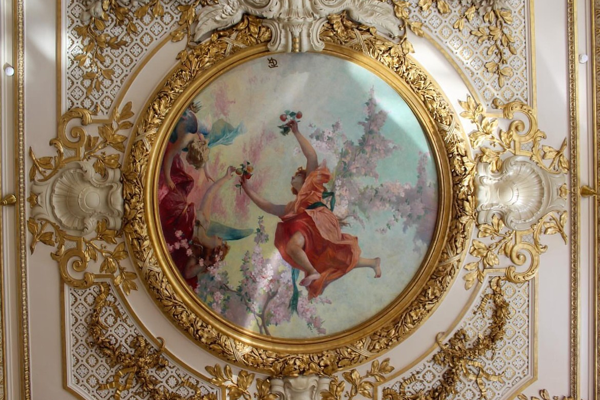

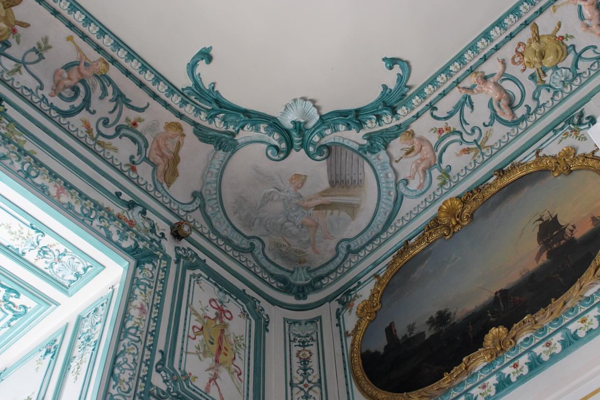

In [ ]:
# Load images to generate captions on - in this example, we will use two input images
image1 = load_image("https://huggingface.co/spaces/HuggingFaceTB/SmolVLM/resolve/main/example_images/rococo.jpg")
image2 = load_image("https://huggingface.co/spaces/HuggingFaceTB/SmolVLM/resolve/main/example_images/rococo_1.jpg")

# Format standard chat prompt before passing instruction to the loaded VLM
question = "Describe the two images."
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"}, #append image 1 to the prompt
            {"type": "image"}, #append image 2 to the prompt
            {"type": "text", "text": question} #append the text question about these images
        ]
    }
]

prompt = processor.apply_chat_template(messages, add_generation_prompt=True) #Apply the chat template to the messages

inputs = processor(text=prompt, images=[image1, image2], return_tensors="pt").to(device) #Prepare the inputs for the model, including the prompt text and the two images. The inputs are returned as PyTorch tensors and moved to the appropriate device (GPU or CPU) for inference.

#Generate text output from the model based on the input images and prompt. We use torch.no_grad() to disable gradient calculations, which reduces memory usage and speeds up inference since we are not training the model.
with torch.no_grad():
    generated_ids = model.generate(**inputs, max_new_tokens=100)
    generated_text = processor.batch_decode(
        generated_ids[:, inputs.input_ids.shape[1]:],
        skip_special_tokens=True
    )

print("\n--- Answer: ---")
print(generated_text[0])

print("\n--- Input images ---")
small_image_display1 = image1.resize((600, 400))
small_image_display2 = image2.resize((600, 400))
display(small_image_display1)
print("\n")
display(small_image_display2)

**Task 2 - Question 2:** Observe the answer produced by the previous code cell. Is the answer output by the model reasonable? Why yes or why not?

**Answer:**

The output by the model is very reasonable. In image one we can see both females inside the gold frame, the while ceiling with the intricate designs are seen in the output as well as the white and blue colour scheme. In image two the woman in the painting is visible as well as the gold frame with blue and white colour schemes. Based on the output results the model is reasonable as all the features of the images are present. As stated in Lecture 8 this is what we should expect from a Vision language model (VLM), it is a defined as a multimodal model that can learn from text and images by taking both the text and image outputs and generating text outputs. It is also important to note a few discrepancies as the model in the first image the text states blue and white colour schemes but image 2 fits that colour scheme more. Also we can see an additional colour schemes (pink and orange) which is not in the image 1 text. SmolVLM sometimes vary in capability as they are efficient but small models. Lecture 8 states that there is diversity within the existing set of VLM’s as well as how they encode images and the data they are trained on, thus their capabilities. This shows that although the outputs are mostly corrected, the model may not always be less precise in terms of description.

VLMs can also be used to answer questions about documents that have been digitised, i.e. OCR (Optical Character Recognition) tasks. In the following code cell, we will query the model about a specific section of a scanned document.

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


Saving document.png to document.png

--- Answer: ---
 P. Carter

--- Input digital document: ---


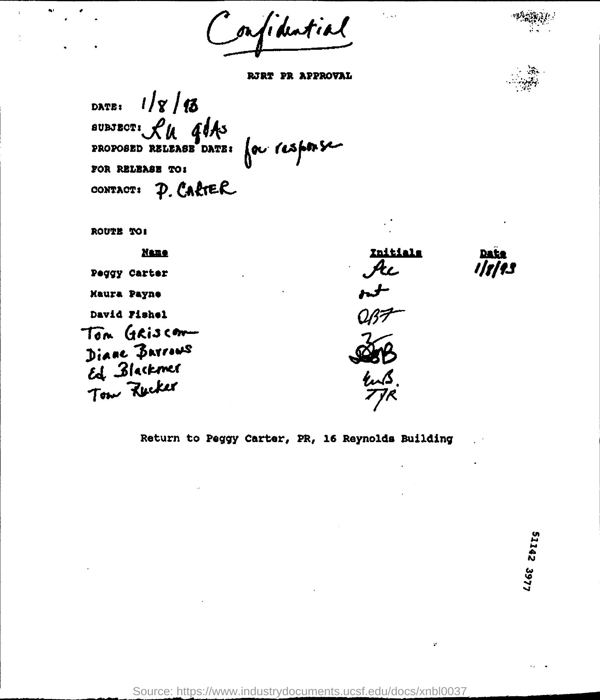

In [ ]:
uploaded = files.upload()
ocr_image_obj = Image.open(list(uploaded.keys())[0]).convert("RGB")

# Format standard chat prompt before passing instruction to the loaded VLM
question = "What is the contact name in this document?"
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"}, #In this case, we only have one image as input
            {"type": "text", "text": question} #And our question is related again to something in that image
        ]
    }
]

prompt = processor.apply_chat_template(messages, add_generation_prompt=True)

inputs = processor(text=prompt, images=[ocr_image_obj], return_tensors="pt").to(device)

#Generate the answer
with torch.no_grad():
    generated_ids = model.generate(**inputs, max_new_tokens=100)
    generated_text = processor.batch_decode(
        generated_ids[:, inputs.input_ids.shape[1]:],
        skip_special_tokens=True
    )

print("\n--- Answer: ---")
print(generated_text[0])

print("\n--- Input digital document: ---")
small_image_display = ocr_image_obj.resize((600, 700))
display(small_image_display)

We can also ask questions about parts of the digitised document that follow a particular format, e.g. dates. This is exemplified in the following code cell.

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`



--- Answer: ---
 1/8/93

--- Input digital document: ---


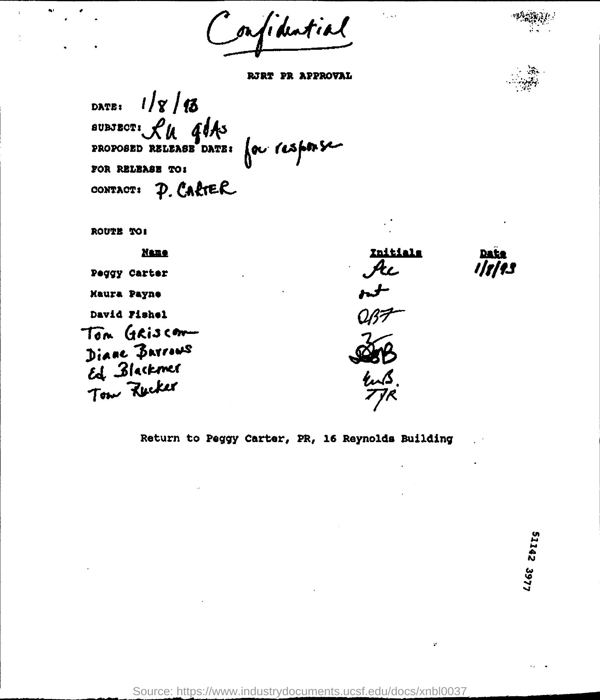

In [ ]:
# Format standard chat prompt before passing instruction to the loaded VLM
question = "What is the proposed release date in this document?"
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": question} #Ask a different question about the same document image, in this case something that looks like a date
        ]
    }
]

prompt = processor.apply_chat_template(messages, add_generation_prompt=True)

inputs = processor(text=prompt, images=[ocr_image_obj], return_tensors="pt").to(device)

# Generate output
with torch.no_grad():
    generated_ids = model.generate(**inputs, max_new_tokens=100)
    generated_text = processor.batch_decode(
        generated_ids[:, inputs.input_ids.shape[1]:],
        skip_special_tokens=True
    )

print("\n--- Answer: ---")
print(generated_text[0])

print("\n--- Input digital document: ---")
small_image_display = ocr_image_obj.resize((600, 700))
display(small_image_display)

**Task 2 - Question 3:** Try changing the question text in the code cell above to "What is the proposed release date in this document?", and check the output text answer. Why do you think the model generates this output? Explain.

**Answer:**

When the question text was changed to “What is the proposed release date in this document?”the models answer is 1/8/93. However when you look at the document you will see that answer is for the main date above and the actual proposed release data is not a number but instead letters that state ‘for response’. As stated previously in Task 2 question 1, 25% of the training data SmolVLM is trained on includes OCR, document understanding and text transcription, which explains why the model generated correctly for contact name (P. Carter) in the cell above. One reason why the model generated this output is because it saw that there isn’t a number next to the proposed release data and instead used a date elsewhere of the same document. Lecture 8 (What is Generative AI?) defines Gen AI as a subset of AI that uses generative models to generate text. They do this by learning underlying structures and patterns of their training data and use them to generate new data. That is evident in this task as the model used a date from some where else or the next closest actual date it knows in the document instead of saying no date. Another reason why I think the model generated this output is because of the complexity of the handwriting. Lecture 8 defines Vision Language Models (VLM) as multimodal models that can learn from images and text however their capabilities depend on the data they were trained on and how they encode images. The model struggles to interpret complex or handwriting its not familiar with so it ends up using a clearer data type that its recognises and its been trained on, which in this case is the date 1/8/93.